**Прогнозирование стоймости страховки**

In [22]:
import os
os.environ['KAGGLE_USERNAME'] ='yuzefita'
os.environ['KAGGLE_KEY'] ='KGAT_d622cb46cd7a6cb07fbd5d44999d5940'

print('ok')

ok


In [23]:
!kaggle datasets download -d "mirichoi0218/insurance"
!unzip insurance.zip

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
insurance.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  insurance.zip
replace insurance.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


 колонки:


*   Age возраст в годах
*   Sex пол


*   bmi индекс массы тела
*   children кол-во детей


*   smoker курит или нет
*   region регион


*   charges стоимость страховки










In [25]:
print("Количество записей\n", df.count())
print("\n статистика:\n", df.describe())
print("\nПропуски \n", df.isnull().sum())


Количество записей
 age         1338
sex         1338
bmi         1338
children    1338
smoker      1338
region      1338
charges     1338
dtype: int64

 статистика:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Пропуски 
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


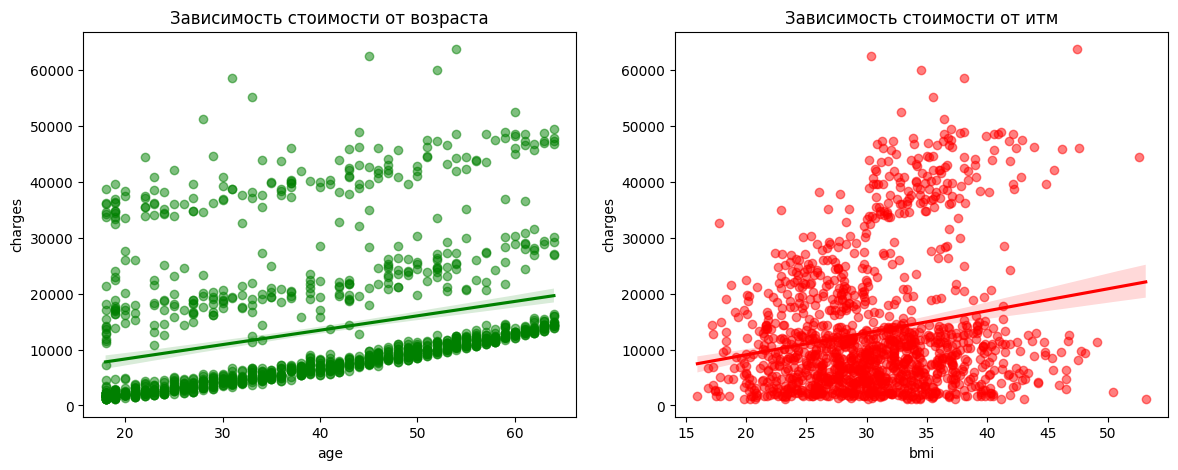

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.regplot(data=df, x='age', y='charges', ax=axes[0],color='green', scatter_kws={'alpha': 0.5})
axes[0].set_title('Зависимость стоимости от возраста')

sns.regplot(data=df, x='bmi', y='charges', color='red', ax=axes[1], scatter_kws={'alpha':0.5})
axes[1].set_title('Зависимость стоимости от итм')
plt.show()

/tmp/ipykernel_2935/3466208840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='charges',ax=axes[0, 0], palette='Pastel1')
/tmp/ipykernel_2935/3466208840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='children', y='charges',ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_2935/3466208840.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges',ax=axes[1,0], palette='Pastel2')
/tmp/ipykernel_2935/3466208840.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is de

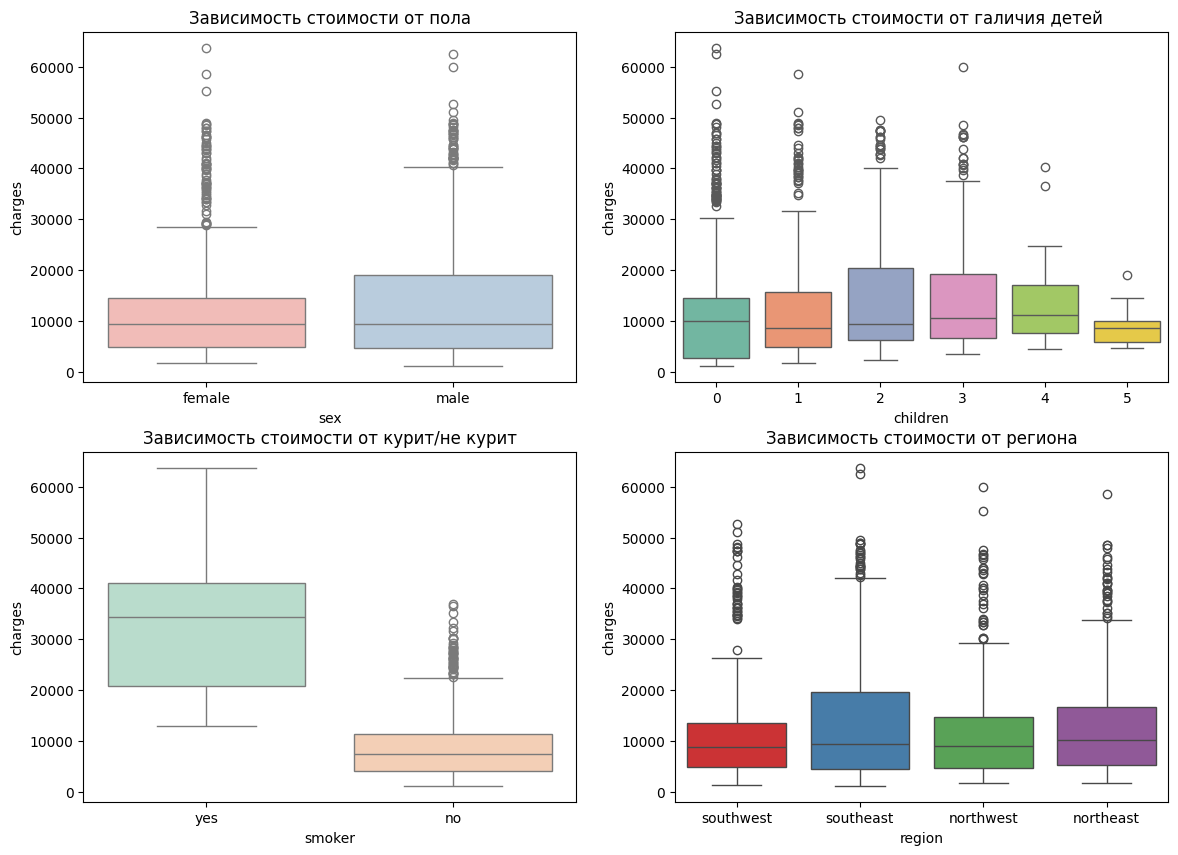

In [27]:
fig, axes=plt.subplots(2,2 ,figsize=(14,10))
sns.boxplot(data=df, x='sex', y='charges',ax=axes[0, 0], palette='Pastel1')
axes[0, 0].set_title('Зависимость стоимости от пола')

sns.boxplot(data=df, x='children', y='charges',ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Зависимость стоимости от галичия детей ')

sns.boxplot(data=df, x='smoker', y='charges',ax=axes[1,0], palette='Pastel2')
axes[1,0].set_title('Зависимость стоимости от курит/не курит')

sns.boxplot(data=df, x='region', y='charges',ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Зависимость стоимости от региона')

plt.show()

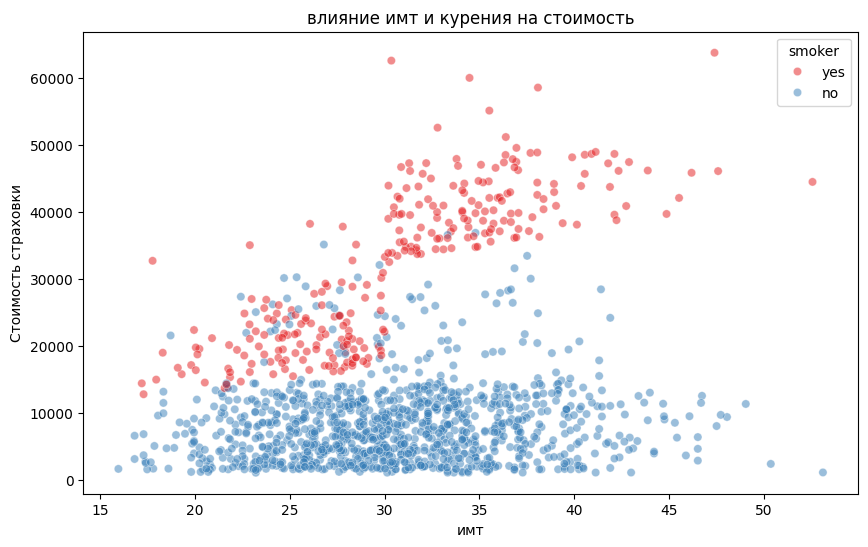

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.5)
plt.title('влияние имт и курения на стоимость')
plt.xlabel('имт')
plt.ylabel('Стоимость страховки')
plt.show()

Стоимость страховки зависит от возраста, чем старше человек становится тем она выше. Зависимость от ИМТ показала, что при превышении порога 30, стоимость страховки увеличивается. Пол не влияет на стоимость страховки. Человек курильщик или нет сильно влияет если курит, то стоимость повышается. Регион не влияет. Наличие детей не особо влияет(При количестве детей до 3 немного растет от 4 до 5 немного уменьшается). При связи признала имт и курильщика видно, что у тех кто курит  при превышении имт 30 резкий рост стоимости страховки

In [29]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


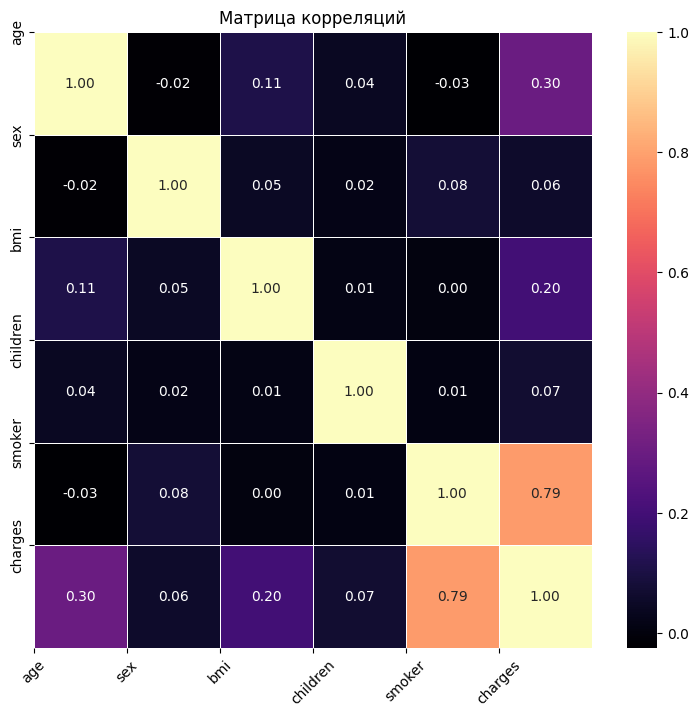

In [30]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9,8))
sns.heatmap(corr, cmap='magma',fmt=".2f", annot=True, linewidth=0.5)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Матрица корреляций')
plt.show()

In [31]:
df = df.drop(['sex','region'], axis=1)

df.head()

,age,bmi,children,smoker,charges
0,19,27.900,0,1,16884.92400
1,18,33.770,1,0,1725.55230
2,28,33.000,3,0,4449.46200
3,33,22.705,0,0,21984.47061
4,32,28.880,0,0,3866.85520


In [32]:
df['smoker_bmi'] = ((df['smoker'] == 1) & (df['bmi'] > 30)).astype(int)
df.head()

,age,bmi,children,smoker,charges,smoker_bmi
0,19,27.900,0,1,16884.92400,0
1,18,33.770,1,0,1725.55230,0
2,28,33.000,3,0,4449.46200,0
3,33,22.705,0,0,21984.47061,0
4,32,28.880,0,0,3866.85520,0


Я удалила признак sex и region потму что они не влияют на изменения стоимости. ДОбавила признак который соблюдает два условия человек курит и имт бльше 30


разделение выборки


In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['charges'])
y=df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state =42)
print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 1070 строк
Тестовая выборка: 268 строк


Я разделила 80 на 20 выборку

In [34]:
import time
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())

]
regression_linear = Pipeline(linear_steps)
start_time = time.time()
regression_linear.fit(X_train, y_train)
time_linear = time.time()- start_time


ridge_steps = [
    ('scaler', StandardScaler() ),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge())

]

ridge_pipe = Pipeline(ridge_steps)
ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}
start_time = time.time()
ridge_grid = GridSearchCV(ridge_pipe,ridge_param_grid, cv = 5,scoring='neg_mean_squared_error' )
ridge_grid.fit(X_train, y_train.to_numpy())
time_ridge = time.time() - start_time

best_ridge = ridge_grid.best_estimator_
print(f"Лучший параметр alpha для Ridge: {ridge_grid.best_params_['model__alpha']}")

lasso_steps = [
   ('scaler', StandardScaler() ),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Lasso())
]
lasso_pipe = Pipeline(lasso_steps)
lasso_param_grid = {'model__alpha': [0.01,0.1, 1.0, 10.0, 100.0]}
start_time = time.time()
lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5 ,scoring='neg_mean_squared_error' )
lasso_grid.fit(X_train, y_train.to_numpy())
time_lasso = time.time() - start_time
best_lasso = lasso_grid.best_estimator_
print(f"Лучший параметр alpha для LAsso: {lasso_grid.best_params_['model__alpha']}")


print('Сравнение скоростей обучения')
print(f'Линейная регрессия:{time_linear:.6f}сек' )
print(f'Ridge:{time_ridge:.6f}сек')
print(f'Lasso:{time_lasso:.6f}сек')

Лучший параметр alpha для Ridge: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.194e+08, tolerance: 1.242e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.100e+08, tolerance: 1.194e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.184e+08, tolerance: 1.266e

Лучший параметр alpha для LAsso: 100.0
Сравнение скоростей обучения
Линейная регрессия:0.034597сек
Ridge:0.313906сек
Lasso:0.506462сек


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.640e+07, tolerance: 1.222e+07
  model = cd_fast.enet_coordinate_descent(


ДЛя базовой линейной регрессии параметры подбирались за один шаг, а для Lasso, Ridge с помощью GridSearchCV чтобы подобрать оптимальный alpha.
Линейная регрессия обучалась быстрее всего потому что ей не нужно было подбирать alpha

In [35]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
y_pred_linear_test = regression_linear.predict(X_test)
y_pred_ridge_test = ridge_grid.predict(X_test)
y_pred_lasso_test = lasso_grid.predict(X_test)

y_pred_linear_train = regression_linear.predict(X_train)
y_pred_ridge_train = ridge_grid.predict(X_train)
y_pred_lasso_train = lasso_grid.predict(X_train)

metrics_data = {
    'linear regression': [
        r2_score(y_train, y_pred_linear_train),
        r2_score(y_test,y_pred_linear_test ),
        np.sqrt(mean_squared_error(y_test,y_pred_linear_test)),
        mean_absolute_percentage_error(y_test,y_pred_linear_test)

    ],

     'Ridge': [
        r2_score(y_train, y_pred_ridge_train),
        r2_score(y_test,y_pred_ridge_test ),
        np.sqrt(mean_squared_error(y_test,y_pred_ridge_test)),
        mean_absolute_percentage_error(y_test,y_pred_ridge_test)

    ],

     'lasso': [
        r2_score(y_train, y_pred_lasso_train),
        r2_score(y_test,y_pred_lasso_test ),
        np.sqrt(mean_squared_error(y_test,y_pred_lasso_test)),
        mean_absolute_percentage_error(y_test,y_pred_lasso_test)

    ]
}
columns = ['R2 (Train)', 'R2 (Test)', 'RMSE (Test)', 'MAPE (Test)']
df_metrics = pd.DataFrame(metrics_data, index=columns).T
print(df_metrics.round(4))

                   R2 (Train)  R2 (Test)  RMSE (Test)  MAPE (Test)
linear regression      0.8652     0.8888    4154.9198       0.3030
Ridge                  0.8652     0.8888    4154.7712       0.3035
lasso                  0.8640     0.8869    4190.4133       0.3210


Я использовала R2, RMSE, MAPE. R2 считала на тренировочных и на тестовых чтобы узнать переобучилась модель или нет. У меня модель вообще не переобучилась пототму что на тесте результат показался выше чем на train. Использовала RMSE а не MAE потому что нам важно если промах большой. Лучше всго справилась модель RIdge

# Дз Random Forest

In [36]:

from sklearn.model_selection import train_test_split
X_rf = df.drop(columns=['charges'])
y_rf=df['charges']
X_rf_encoded = pd.get_dummies(X_rf, drop_first=True)
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf_encoded, y_rf, test_size=0.2, random_state=42)
X_rf_train.head(3)

,age,bmi,children,smoker,smoker_bmi
560,46,19.95,2,0,0
1285,47,24.32,0,0,0
1142,52,24.86,0,0,0


* **Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если до, то почему?**

Да сделала, преобразовала текстовые признаки в бинарные. Так же здесь не нужно масштабирование как в линейной регрессии, потому что дерево решений делает разделение на основе правил сравнения и масштаб ему не важен.


* **Как именно вы разделили выборку?**

я разделила выборну на train test 80 на 20
* **На сколько частей нужно делить выборку при использовании кросс-валидации?**

по разному зависит от колчества данных может 5 или 10 быть. к примеру если 5, то на 4 она обучаетсяя а 1 использует для валидации
* **Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае?**

можно не использовать тогда просто методом train_test_split

In [37]:
import time
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
MAX = 5
tree_start = time.time()
tree_model = DecisionTreeRegressor(max_depth=MAX, random_state = 42)
tree_model.fit(X_rf_train, y_rf_train)
tree_end = time.time()
tree_time = tree_end - tree_start

forest_start = time.time()

forest_model = RandomForestRegressor(n_estimators=100, max_depth=MAX, random_state = 42,n_jobs=-1 )
forest_model.fit(X_rf_train, y_rf_train)
forest_end = time.time()
forest_time = forest_end - forest_start

print(f"Время обучения одного дерева: {tree_time:.4f} секунд")
print(f"Время обучения случайного леса: {forest_time:.4f} секунд")

Время обучения одного дерева: 0.0056 секунд
Время обучения случайного леса: 0.2110 секунд


* **Сравнение скорости:** сравните, какая модель обучалась быстрее.

быстрее обучилось одно дерево
* **Можно ли добиться одинаковой или близкой к одинаковой скорости?**

одинаковой нельзя, а близкой к одинаковой можно путем уменьшения количества деревьев n_estimators=1, но это бессмысленно.надо использовать параметр n_jobs=-1 который позволяет параллельно вычислять деревья

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np
y_pred_tree_train = tree_model.predict(X_rf_train)
y_pred_tree_test = tree_model.predict(X_rf_test)

y_pred_forest_train = forest_model.predict(X_rf_train)
y_pred_forest_test = forest_model.predict(X_rf_test)

rf_metrics_data = {
    'Decision Tree': [
        r2_score(y_rf_train, y_pred_tree_train),
        r2_score(y_rf_test, y_pred_tree_test),
        np.sqrt(mean_squared_error(y_rf_test, y_pred_tree_test)),
        mean_absolute_percentage_error(y_rf_test, y_pred_tree_test)
    ],
    'Random Forest': [
        r2_score(y_rf_train, y_pred_forest_train),
        r2_score(y_rf_test, y_pred_forest_test),
        np.sqrt(mean_squared_error(y_rf_test, y_pred_forest_test)),
        mean_absolute_percentage_error(y_rf_test, y_pred_forest_test)
    ]
}

columns = ['R2 (Train)', 'R2 (Test)', 'RMSE (Test)', 'MAPE (Test)']
df_rf_metrics = pd.DataFrame(rf_metrics_data, index=columns).T

print(" сравненение дерева и случайного леса ")
print(df_rf_metrics.round(4))

 сравненение дерева и случайного леса 
               R2 (Train)  R2 (Test)  RMSE (Test)  MAPE (Test)
Decision Tree      0.8718     0.8416    4958.5855       0.3356
Random Forest      0.8789     0.8758    4390.5301       0.3269


случайный лес показывает лучшие результаты, потому что он усредняет все предсказания делает их более точными ну и уменьшает ошибку модели

In [40]:

final_metrics_clean = {
    'Linear Regression': [
        r2_score(y_train, y_pred_linear_train),
        r2_score(y_test, y_pred_linear_test),
        np.sqrt(mean_squared_error(y_test, y_pred_linear_test)),
        mean_absolute_percentage_error(y_test, y_pred_linear_test)
    ],
    'Ridge': [
        r2_score(y_train, y_pred_ridge_train),
        r2_score(y_test, y_pred_ridge_test),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge_test)),
        mean_absolute_percentage_error(y_test, y_pred_ridge_test)
    ],
    'Lasso': [
        r2_score(y_train, y_pred_lasso_train),
        r2_score(y_test, y_pred_lasso_test),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso_test)),
        mean_absolute_percentage_error(y_test, y_pred_lasso_test)
    ],
    'Decision Tree': [
        r2_score(y_rf_train, y_pred_tree_train),
        r2_score(y_rf_test, y_pred_tree_test),
        np.sqrt(mean_squared_error(y_rf_test, y_pred_tree_test)),
        mean_absolute_percentage_error(y_rf_test, y_pred_tree_test)
    ],
    'Random Forest': [
        r2_score(y_rf_train, y_pred_forest_train),
        r2_score(y_rf_test, y_pred_forest_test),
        np.sqrt(mean_squared_error(y_rf_test, y_pred_forest_test)),
        mean_absolute_percentage_error(y_rf_test, y_pred_forest_test)
    ]
}

columns = ['R2 (Train)', 'R2 (Test)', 'RMSE (Test)', 'MAPE (Test)']
df_final = pd.DataFrame(final_metrics_clean, index=columns).T
df_final.round(4)

,R2 (Train),R2 (Test),RMSE (Test),MAPE (Test)
Linear Regression,0.8652,0.8888,4154.9198,0.3030
Ridge,0.8652,0.8888,4154.7712,0.3035
Lasso,0.8640,0.8869,4190.4133,0.3210
Decision Tree,0.8718,0.8416,4958.5855,0.3356
Random Forest,0.8789,0.8758,4390.5301,0.3269


3. **Какая модель по итогу справилась лучше?**

линейная регрессия

4. **Насколько хорошие получились результаты?**
достаточно 87% обьясняется моей моделью